In [1]:
# -*- coding: utf-8 -*-
"""
Random Forest 正式建模：SUNNY与HEATWAVE平均LST（90 m缓冲区）

主要步骤
--------
1. 对SUNNY与HEATWAVE分别删除 LST=0 和 LST 缺失样本；
2. 按 70%训练集、30%测试集划分数据；
3. 仅在训练集内使用 RandomizedSearchCV + 5折交叉验证调参；
4. 搜索最佳 ntree、mtry、min.node.size；
5. 使用最佳模型计算训练集与独立测试集 R²、RMSE；
6. 使用最佳参数在全部完整案例样本上重建解释模型；
7. 通过 shap.TreeExplainer 计算 Random Forest TreeSHAP；
8. 输出参数、性能、预测结果、SHAP重要性以及图件。

参数名称对应关系
----------------
ntree         -> sklearn: n_estimators
mtry          -> sklearn: max_features
min.node.size -> sklearn: min_samples_leaf

首次运行如缺少依赖，请在 Jupyter Notebook 中执行：
!pip install pandas numpy scipy scikit-learn matplotlib shap openpyxl xlrd
"""

# =============================================================================
# 0. 导入库
# =============================================================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import (
    RandomizedSearchCV,
    train_test_split,
)

warnings.filterwarnings("ignore")


# =============================================================================
# 1. 文件路径与基础参数
# =============================================================================
DATA_PATH = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\data\wuhuanshiliang\SH_attributes.xls"
)

OUTPUT_DIR = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\脚本\Python\importance"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = [
    "SUNNY",
    "HEATWAVE",
]

TARGET_LABEL_MAP = {
    "SUNNY": "Sunny-day mean LST",
    "HEATWAVE": "Heatwave mean LST",
}

RANDOM_STATE = 123

# 这里采用70%训练集、30%测试集。
# 即训练集:测试集 = 70:30。
TEST_SIZE = 0.30

# 随机搜索次数与交叉验证折数
N_ITER_SEARCH = 50
CV_FOLDS = 5

# 90 m 模型的固定变量
FIXED_VARS = [
    "TCC",
    "GCI",
    "BCI",
    "WCI",
    "RCI",
    "Shape_Area",
    "jungong",
    "BAH",
    "BHSD",
    "DIST",
]

# 90 m 缓冲区变量
BUFFER_VARS_90M = [
    "TCC_b90m",
    "GCI_b90m",
    "BCI_b90m",
    "WCI_b90m",
    "RCI_b90m",
    "BAH_b90m",
    "BHSD_b90m",
]

INDEPENDENT_VARS = FIXED_VARS + BUFFER_VARS_90M

# 变量显示名称
VAR_NAME_MAP = {
    "TCC": "TCC",
    "GCI": "GCI",
    "BCI": "BCI",
    "WCI": "WCI",
    "RCI": "RCI",
    "Shape_Area": "Area",
    "jungong": "CY",
    "BAH": "BAH",
    "BHSD": "BHSD",
    "DIST": "DIST",
    "TCC_b90m": "TCC_buffer",
    "GCI_b90m": "GCI_buffer",
    "BCI_b90m": "BCI_buffer",
    "WCI_b90m": "WCI_buffer",
    "RCI_b90m": "RCI_buffer",
    "BAH_b90m": "BAH_buffer",
    "BHSD_b90m": "BHSD_buffer",
}

DISPLAY_VARS = [VAR_NAME_MAP[v] for v in INDEPENDENT_VARS]


# =============================================================================
# 2. 工具函数
# =============================================================================
def validate_columns(df: pd.DataFrame) -> None:
    """检查建模所需字段是否全部存在。"""
    required = set(TARGETS + INDEPENDENT_VARS)
    missing = sorted(required.difference(df.columns))

    if missing:
        raise KeyError(
            "数据中缺少以下必要字段：\n" + "\n".join(missing)
        )


def prepare_target_data(
    df: pd.DataFrame,
    target: str,
) -> tuple[pd.DataFrame, pd.Series, pd.Index]:
    """
    为一个因变量准备数据。

    处理规则：
    1. 所有建模字段转换为数值；
    2. 正负无穷转为NaN；
    3. 因变量等于0时按缺失值处理；
    4. 删除因变量或任一自变量存在缺失值的整行；
    5. 不进行任何缺失值填补。
    """
    selected = df[[target] + INDEPENDENT_VARS].copy()

    selected = selected.apply(pd.to_numeric, errors="coerce")
    selected.replace([np.inf, -np.inf], np.nan, inplace=True)

    # LST=0 表示缺失
    selected.loc[selected[target] == 0, target] = np.nan

    # 记录完整案例删除前后的样本变化
    n_before_drop = len(selected)

    # 删除因变量或任一自变量存在缺失值的整行
    selected = selected.dropna(
        subset=[target] + INDEPENDENT_VARS
    ).copy()

    n_removed = n_before_drop - len(selected)
    print(
        f"{target}: 因变量或自变量缺失共删除 {n_removed} 行，"
        f"保留 {len(selected)} 行完整案例。"
    )

    if len(selected) < 50:
        raise ValueError(
            f"{target} 仅有 {len(selected)} 个有效样本，不建议进行当前建模。"
        )

    X = selected[INDEPENDENT_VARS].copy()
    y = selected[target].astype(float).copy()
    original_index = selected.index.copy()

    return X, y, original_index


def build_search() -> RandomizedSearchCV:
    """
    构建随机森林随机调参对象。

    数据在进入该函数前已经完成完整案例删除，因此这里不进行
    任何缺失值填补。五折交叉验证仅在训练集内部执行。
    """
    rf = RandomForestRegressor(
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    n_features = len(INDEPENDENT_VARS)

    # RandomizedSearchCV 的离散随机搜索空间
    param_distributions = {
        # ntree：500–2000
        "n_estimators": randint(500, 2001),

        # mtry：3–全部17个变量
        "max_features": randint(3, n_features + 1),

        # min.node.size：1–15
        "min_samples_leaf": randint(1, 16),
    }

    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_distributions,
        n_iter=N_ITER_SEARCH,
        scoring="neg_root_mean_squared_error",
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
        refit=True,
    )

    return search

def calculate_metrics(
    y_true: pd.Series | np.ndarray,
    y_pred: np.ndarray,
) -> tuple[float, float]:
    """计算R²与RMSE。"""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return float(r2), float(rmse)


def extract_shap_values(
    explainer: shap.TreeExplainer,
    X_array: np.ndarray,
) -> np.ndarray:
    """
    兼容不同SHAP版本，提取二维回归SHAP矩阵。
    """
    explanation = explainer(X_array)
    values = explanation.values

    # 一般RF回归结果为 n_samples × n_features
    if values.ndim == 2:
        return values

    # 某些版本可能额外返回一个输出维度
    if values.ndim == 3 and values.shape[-1] == 1:
        return values[:, :, 0]

    raise ValueError(
        f"无法识别SHAP矩阵维度：{values.shape}"
    )


def save_shap_bar(
    importance_df: pd.DataFrame,
    target: str,
) -> None:
    """绘制单独的Mean |SHAP|变量重要性图。"""
    plot_df = (
        importance_df
        .sort_values("MeanAbsSHAP", ascending=True)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(8.5, 7.2), dpi=180)

    ax.barh(
        plot_df["Variable_Label"],
        plot_df["MeanAbsSHAP"],
        color="lightpink",
        alpha=0.60,
        edgecolor="black",
        linewidth=0.6,
    )

    max_value = plot_df["MeanAbsSHAP"].max()

    for i, row in plot_df.iterrows():
        ax.text(
            row["MeanAbsSHAP"] + max_value * 0.015,
            i,
            (
                f'{row["MeanAbsSHAP"]:.2f} '
                f'({row["RelativeImportance_percent"]:.1f}%)'
            ),
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
        )

    ax.set_xlabel(
        "Mean |SHAP Value|",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_ylabel("")
    ax.set_title(
        TARGET_LABEL_MAP.get(target, target),
        fontsize=16,
        fontweight="bold",
    )

    ax.tick_params(
        axis="both",
        labelsize=11,
        width=1.2,
        direction="out",
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(False)

    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR / f"{target}_RF_SHAP_importance.png",
        dpi=600,
        bbox_inches="tight",
    )
    fig.savefig(
        OUTPUT_DIR / f"{target}_RF_SHAP_importance.pdf",
        bbox_inches="tight",
    )
    plt.close(fig)


def save_shap_beeswarm(
    shap_values: np.ndarray,
    X_display: pd.DataFrame,
    target: str,
) -> None:
    """绘制单独的SHAP摘要蜂群图。"""
    expl = shap.Explanation(
        values=shap_values,
        data=X_display.values,
        feature_names=X_display.columns.tolist(),
    )

    fig, ax = plt.subplots(figsize=(9.5, 7.2), dpi=180)

    shap.plots.beeswarm(
        expl,
        ax=ax,
        show=False,
        plot_size=None,
        max_display=X_display.shape[1],
    )

    for collection in ax.collections:
        collection.set_alpha(0.70)

    ax.set_xlabel(
        "SHAP Value",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_title(
        TARGET_LABEL_MAP.get(target, target),
        fontsize=16,
        fontweight="bold",
    )

    ax.tick_params(
        axis="both",
        labelsize=11,
        width=1.2,
        direction="out",
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.grid(False)

    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR / f"{target}_RF_SHAP_beeswarm.png",
        dpi=600,
        bbox_inches="tight",
    )
    fig.savefig(
        OUTPUT_DIR / f"{target}_RF_SHAP_beeswarm.pdf",
        bbox_inches="tight",
    )
    plt.close(fig)


def save_overlay_plot(
    shap_values: np.ndarray,
    X_display: pd.DataFrame,
    importance_df: pd.DataFrame,
    target: str,
) -> None:
    """
    绘制与用户示例风格接近的：
    Mean(|SHAP|)横向柱状图 + SHAP beeswarm 双X轴叠加图。
    """
    plot_df = (
        importance_df
        .sort_values("MeanAbsSHAP", ascending=False)
        .reset_index(drop=True)
    )

    ordered_vars = plot_df["Variable"].tolist()
    ordered_labels = plot_df["Variable_Label"].tolist()

    ordered_indices = [
        INDEPENDENT_VARS.index(v) for v in ordered_vars
    ]

    shap_values_sorted = shap_values[:, ordered_indices]

    X_sorted = X_display[
        [VAR_NAME_MAP[v] for v in ordered_vars]
    ].copy()

    mean_shap_sorted = plot_df["MeanAbsSHAP"].to_numpy()
    n_feat = len(ordered_labels)

    # 与示例保持一致：第一个变量位于最上方
    y_pos = np.arange(n_feat)[::-1]

    fig = plt.figure(figsize=(11, 7), dpi=180)

    ax_sw = fig.add_axes([0.28, 0.12, 0.58, 0.76])
    ax_bar = ax_sw.twiny()

    ax_bar.set_zorder(0)
    ax_sw.set_zorder(1)
    ax_sw.patch.set_alpha(0)

    # -------------------------------------------------------------------------
    # 底层：Mean(|SHAP|)柱状图
    # -------------------------------------------------------------------------
    ax_bar.barh(
        y=y_pos,
        width=mean_shap_sorted,
        height=0.65,
        color="lightpink",
        alpha=0.45,
        edgecolor="black",
        linewidth=0.5,
        zorder=0,
    )

    xlim_bar = mean_shap_sorted.max() * 1.20
    ax_bar.set_xlim(0, xlim_bar)

    xticks_bar = np.linspace(0, xlim_bar, 5)
    ax_bar.set_xticks(xticks_bar)
    ax_bar.set_xticklabels(
        [f"{x:.2f}" for x in xticks_bar],
        fontsize=12,
        fontweight="bold",
    )

    ax_bar.set_xlabel(
        "Mean |SHAP Value|",
        fontsize=14,
        fontweight="bold",
    )
    ax_bar.xaxis.set_label_position("top")
    ax_bar.xaxis.tick_top()
    ax_bar.set_yticks(y_pos)

    # -------------------------------------------------------------------------
    # 上层：SHAP beeswarm
    # -------------------------------------------------------------------------
    expl = shap.Explanation(
        values=shap_values_sorted,
        data=X_sorted.values,
        feature_names=ordered_labels,
    )

    plt.sca(ax_sw)

    shap.plots.beeswarm(
        expl,
        ax=ax_sw,
        show=False,
        plot_size=None,
        max_display=n_feat,
    )

    for collection in ax_sw.collections:
        collection.set_alpha(0.70)
        old_sizes = collection.get_sizes()
        if old_sizes is not None and len(old_sizes) > 0:
            collection.set_sizes(old_sizes * 1.0)

    for label in ax_sw.get_xticklabels():
        label.set_fontsize(12)
        label.set_fontweight("bold")

    ax_sw.set_yticks(y_pos)
    ax_sw.set_yticklabels(
        ordered_labels,
        fontsize=13,
        fontweight="bold",
    )

    ax_sw.set_xlabel(
        "SHAP Value",
        fontsize=14,
        fontweight="bold",
    )

    # -------------------------------------------------------------------------
    # 数值标签：MeanAbsSHAP + 相对重要性
    # -------------------------------------------------------------------------
    xmin, xmax = ax_sw.get_xlim()
    text_x = xmin + 0.02 * (xmax - xmin)

    for i, row_i in plot_df.iterrows():
        ax_sw.text(
            x=text_x,
            y=y_pos[i],
            s=(
                f'{row_i["MeanAbsSHAP"]:.2f} '
                f'({row_i["RelativeImportance_percent"]:.1f}%)'
            ),
            va="center",
            ha="left",
            fontsize=10.5,
            fontweight="bold",
            color="black",
            zorder=999,
            clip_on=False,
        )

    # -------------------------------------------------------------------------
    # 坐标轴与样式
    # -------------------------------------------------------------------------
    ax_sw.tick_params(
        axis="x",
        labelsize=12,
        width=1.2,
        direction="out",
    )
    ax_sw.tick_params(
        axis="y",
        labelsize=13,
        width=1.2,
        direction="out",
    )
    ax_bar.tick_params(
        axis="x",
        labelsize=12,
        width=1.2,
        direction="out",
    )
    ax_bar.tick_params(axis="y", length=0)

    for ax in [ax_sw, ax_bar]:
        ax.spines["left"].set_linewidth(1.2)
        ax.spines["bottom"].set_linewidth(1.2)
        ax.spines["top"].set_linewidth(1.2)
        ax.spines["right"].set_visible(False)

    ax_sw.grid(False)
    ax_bar.grid(
        axis="x",
        linestyle=":",
        linewidth=0.7,
        alpha=0.45,
    )

    ax_sw.set_title(
        TARGET_LABEL_MAP.get(target, target),
        fontsize=16,
        fontweight="bold",
        pad=18,
    )

    fig.savefig(
        OUTPUT_DIR / f"{target}_RF_SHAP_Bar_Beeswarm_Overlay.png",
        dpi=600,
        bbox_inches="tight",
    )
    fig.savefig(
        OUTPUT_DIR / f"{target}_RF_SHAP_Bar_Beeswarm_Overlay.pdf",
        bbox_inches="tight",
    )
    plt.close(fig)


# =============================================================================
# 3. 主程序
# =============================================================================
def main() -> None:
    print("=" * 80)
    print("读取数据")
    print("=" * 80)

    df = pd.read_excel(
        DATA_PATH,
        sheet_name=0,
        engine="xlrd",
    )

    print(f"数据维度：{df.shape[0]} 行 × {df.shape[1]} 列")

    validate_columns(df)
    print("字段检查通过。")

    all_metrics = []
    all_best_params = []
    all_importance = []
    all_cv_results = []
    all_predictions = []

    for target in TARGETS:
        print("\n" + "=" * 80)
        print(f"Processing: {target}")
        print("=" * 80)

        X, y, original_index = prepare_target_data(df, target)

        print(f"有效样本数：{len(y)}")
        print(f"自变量数量：{X.shape[1]}")

        # ---------------------------------------------------------------------
        # 3.1 固定划分：70%训练、30%测试
        # ---------------------------------------------------------------------
        (
            X_train,
            X_test,
            y_train,
            y_test,
            idx_train,
            idx_test,
        ) = train_test_split(
            X,
            y,
            original_index,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            shuffle=True,
        )

        print(f"训练集样本数：{len(y_train)}")
        print(f"测试集样本数：{len(y_test)}")

        # ---------------------------------------------------------------------
        # 3.2 仅在训练集内做随机搜索 + 五折交叉验证
        # ---------------------------------------------------------------------
        search = build_search()
        search.fit(X_train, y_train)

        best_pipeline = search.best_estimator_
        best_params_raw = search.best_params_

        best_ntree = int(best_params_raw["n_estimators"])
        best_mtry = int(best_params_raw["max_features"])
        best_min_node_size = int(
            best_params_raw["min_samples_leaf"]
        )

        print("\n最佳超参数：")
        print(f"ntree = {best_ntree}")
        print(f"mtry = {best_mtry}")
        print(f"min.node.size = {best_min_node_size}")
        print(
            "Best 5-fold CV RMSE = "
            f"{-search.best_score_:.4f}"
        )

        # ---------------------------------------------------------------------
        # 3.3 训练集与独立测试集性能
        # ---------------------------------------------------------------------
        pred_train = best_pipeline.predict(X_train)
        pred_test = best_pipeline.predict(X_test)

        train_r2, train_rmse = calculate_metrics(
            y_train,
            pred_train,
        )
        test_r2, test_rmse = calculate_metrics(
            y_test,
            pred_test,
        )

        print("\n模型性能：")
        print(
            f"Train R²={train_r2:.4f}, "
            f"Train RMSE={train_rmse:.4f}"
        )
        print(
            f"Test R²={test_r2:.4f}, "
            f"Test RMSE={test_rmse:.4f}"
        )

        all_metrics.append(
            {
                "LST": target,
                "n_total": int(len(y)),
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                "train_ratio": float(1 - TEST_SIZE),
                "test_ratio": float(TEST_SIZE),
                "cv_folds": CV_FOLDS,
                "random_search_iterations": N_ITER_SEARCH,
                "best_cv_rmse": float(-search.best_score_),
                "train_r2": train_r2,
                "train_rmse": train_rmse,
                "test_r2": test_r2,
                "test_rmse": test_rmse,
            }
        )

        all_best_params.append(
            {
                "LST": target,
                "ntree": best_ntree,
                "mtry": best_mtry,
                "min.node.size": best_min_node_size,
                "random_state": RANDOM_STATE,
                "selection_metric": "5-fold CV RMSE",
            }
        )

        # 保存训练集和测试集预测
        pred_train_df = pd.DataFrame(
            {
                "LST": target,
                "dataset": "train",
                "original_row_index": idx_train,
                "observed": np.asarray(y_train),
                "predicted": pred_train,
                "residual": np.asarray(y_train) - pred_train,
            }
        )

        pred_test_df = pd.DataFrame(
            {
                "LST": target,
                "dataset": "test",
                "original_row_index": idx_test,
                "observed": np.asarray(y_test),
                "predicted": pred_test,
                "residual": np.asarray(y_test) - pred_test,
            }
        )

        all_predictions.extend(
            [pred_train_df, pred_test_df]
        )

        # 保存全部随机搜索结果
        cv_result = pd.DataFrame(search.cv_results_)
        cv_result.insert(0, "LST", target)

        cv_result["ntree"] = cv_result[
            "param_n_estimators"
        ].astype(int)
        cv_result["mtry"] = cv_result[
            "param_max_features"
        ].astype(int)
        cv_result["min.node.size"] = cv_result[
            "param_min_samples_leaf"
        ].astype(int)
        cv_result["mean_cv_rmse"] = (
            -cv_result["mean_test_score"]
        )
        cv_result["sd_cv_rmse"] = cv_result[
            "std_test_score"
        ]

        all_cv_results.append(cv_result)

        # ---------------------------------------------------------------------
        # 3.4 用最佳参数在全部有效样本上重建解释模型
        # ---------------------------------------------------------------------
        # 性能指标仍来自上面的独立测试集；
        # 这里使用全部完整案例样本，仅为了获得更稳定的SHAP解释。
        X_full = X.to_numpy(dtype=float)

        final_rf = RandomForestRegressor(
            n_estimators=best_ntree,
            max_features=best_mtry,
            min_samples_leaf=best_min_node_size,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        final_rf.fit(X_full, y)

        # TreeSHAP
        explainer = shap.TreeExplainer(final_rf)
        shap_values = extract_shap_values(
            explainer,
            X_full,
        )

        print("X shape:", X_full.shape)
        print("SHAP shape:", shap_values.shape)

        # 使用完整案例数据绘图；前面已删除所有缺失值
        X_display = pd.DataFrame(
            X_full,
            columns=DISPLAY_VARS,
            index=X.index,
        )

        mean_abs_shap = np.abs(shap_values).mean(axis=0)

        importance_df = pd.DataFrame(
            {
                "LST": target,
                "Variable": INDEPENDENT_VARS,
                "Variable_Label": DISPLAY_VARS,
                "MeanAbsSHAP": mean_abs_shap,
            }
        )

        importance_df["RelativeImportance_percent"] = (
            importance_df["MeanAbsSHAP"]
            / importance_df["MeanAbsSHAP"].sum()
            * 100
        )

        importance_df = importance_df.sort_values(
            "MeanAbsSHAP",
            ascending=False,
        ).reset_index(drop=True)

        all_importance.append(importance_df)

        print("\nSHAP变量重要性：")
        print(
            importance_df[
                [
                    "Variable",
                    "MeanAbsSHAP",
                    "RelativeImportance_percent",
                ]
            ].to_string(index=False)
        )

        # ---------------------------------------------------------------------
        # 3.5 绘图
        # ---------------------------------------------------------------------
        save_shap_bar(
            importance_df=importance_df,
            target=target,
        )

        save_shap_beeswarm(
            shap_values=shap_values,
            X_display=X_display,
            target=target,
        )

        save_overlay_plot(
            shap_values=shap_values,
            X_display=X_display,
            importance_df=importance_df,
            target=target,
        )

    # =========================================================================
    # 4. 汇总并保存结果
    # =========================================================================
    metrics_df = pd.DataFrame(all_metrics)
    best_params_df = pd.DataFrame(all_best_params)
    importance_all_df = pd.concat(
        all_importance,
        ignore_index=True,
    )
    cv_results_all_df = pd.concat(
        all_cv_results,
        ignore_index=True,
    )
    predictions_all_df = pd.concat(
        all_predictions,
        ignore_index=True,
    )

    # CSV
    metrics_df.to_csv(
        OUTPUT_DIR / "RF_model_performance.csv",
        index=False,
        encoding="utf-8-sig",
    )

    best_params_df.to_csv(
        OUTPUT_DIR / "RF_best_parameters.csv",
        index=False,
        encoding="utf-8-sig",
    )

    importance_all_df.to_csv(
        OUTPUT_DIR / "RF_SHAP_MeanAbsImportance.csv",
        index=False,
        encoding="utf-8-sig",
    )

    predictions_all_df.to_csv(
        OUTPUT_DIR / "RF_train_test_predictions.csv",
        index=False,
        encoding="utf-8-sig",
    )

    # Excel总表
    excel_path = OUTPUT_DIR / "RF_formal_model_results.xlsx"

    with pd.ExcelWriter(
        excel_path,
        engine="openpyxl",
    ) as writer:
        metrics_df.to_excel(
            writer,
            sheet_name="model_performance",
            index=False,
        )
        best_params_df.to_excel(
            writer,
            sheet_name="best_parameters",
            index=False,
        )
        importance_all_df.to_excel(
            writer,
            sheet_name="SHAP_importance",
            index=False,
        )
        predictions_all_df.to_excel(
            writer,
            sheet_name="predictions",
            index=False,
        )

        # Excel单个sheet最大约104万行；本任务远低于该限制
        selected_cv_cols = [
            "LST",
            "rank_test_score",
            "ntree",
            "mtry",
            "min.node.size",
            "mean_cv_rmse",
            "sd_cv_rmse",
            "mean_train_score",
            "std_train_score",
            "mean_fit_time",
        ]
        cv_results_all_df[
            selected_cv_cols
        ].sort_values(
            ["LST", "rank_test_score"]
        ).to_excel(
            writer,
            sheet_name="random_search_results",
            index=False,
        )

    print("\n" + "=" * 80)
    print("全部完成")
    print("=" * 80)
    print(f"结果目录：{OUTPUT_DIR}")
    print(f"Excel总表：{excel_path}")

    print("\n最佳参数：")
    print(best_params_df.to_string(index=False))

    print("\n独立测试集性能：")
    print(
        metrics_df[
            [
                "LST",
                "test_r2",
                "test_rmse",
                "best_cv_rmse",
            ]
        ].to_string(index=False)
    )


if __name__ == "__main__":
    main()

读取数据
数据维度：1337 行 × 166 列
字段检查通过。

Processing: SUNNY
SUNNY: 因变量或自变量缺失共删除 0 行，保留 1337 行完整案例。
有效样本数：1337
自变量数量：17
训练集样本数：935
测试集样本数：402
Fitting 5 folds for each of 50 candidates, totalling 250 fits

最佳超参数：
ntree = 1343
mtry = 8
min.node.size = 1
Best 5-fold CV RMSE = 0.9801

模型性能：
Train R²=0.9517, Train RMSE=0.3558
Test R²=0.5956, Test RMSE=0.9658
X shape: (1337, 17)
SHAP shape: (1337, 17)

SHAP变量重要性：
  Variable  MeanAbsSHAP  RelativeImportance_percent
  TCC_b90m     0.315265                   14.571473
   jungong     0.304612                   14.079071
  BCI_b90m     0.273189                   12.626695
       BCI     0.269995                   12.479069
      BHSD     0.203313                    9.397062
       BAH     0.167865                    7.758649
       TCC     0.145020                    6.702787
       GCI     0.131852                    6.094152
 BHSD_b90m     0.067902                    3.138389
  GCI_b90m     0.061712                    2.852319
  BAH_b90m     0.058457   

In [ ]:
# =============================================================================
# 独立Cell：绘制TCC_buffer在SUNNY与HEATWAVE下的SHAP依赖图
# =============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")


# =============================================================================
# 1. 路径与参数
# =============================================================================
DATA_PATH = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\data\wuhuanshiliang\SH_attributes.xls"
)

OUTPUT_DIR = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\脚本\Python\importance"
)

BEST_PARAMS_PATH = OUTPUT_DIR / "RF_best_parameters.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = ["SUNNY", "HEATWAVE"]

TARGET_LABEL_MAP = {
    "SUNNY": "Sunny-day mean LST",
    "HEATWAVE": "Heatwave mean LST",
}

RANDOM_STATE = 123

INDEPENDENT_VARS = [
    "TCC",
    "GCI",
    "BCI",
    "WCI",
    "RCI",
    "Shape_Area",
    "jungong",
    "BAH",
    "BHSD",
    "DIST",
    "TCC_b90m",
    "GCI_b90m",
    "BCI_b90m",
    "WCI_b90m",
    "RCI_b90m",
    "BAH_b90m",
    "BHSD_b90m",
]

DEPENDENCE_VARIABLE = "TCC_b90m"
DEPENDENCE_LABEL = "TCC_buffer"


# =============================================================================
# 2. SHAP值提取函数
# =============================================================================
def extract_shap_values(
    explainer,
    X_array: np.ndarray,
) -> np.ndarray:
    """兼容不同SHAP版本，返回二维SHAP矩阵。"""

    explanation = explainer(X_array)
    values = explanation.values

    if values.ndim == 2:
        return values

    if values.ndim == 3 and values.shape[-1] == 1:
        return values[:, :, 0]

    raise ValueError(
        f"无法识别SHAP矩阵维度：{values.shape}"
    )


# =============================================================================
# 3. 读取原始数据和已经选出的最佳参数
# =============================================================================
df = pd.read_excel(
    DATA_PATH,
    sheet_name=0,
    engine="xlrd",
)

best_params_df = pd.read_csv(
    BEST_PARAMS_PATH,
    encoding="utf-8-sig",
)

required_columns = (
    TARGETS
    + INDEPENDENT_VARS
)

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise KeyError(
        "原始数据缺少以下字段：\n"
        + "\n".join(missing_columns)
    )

if DEPENDENCE_VARIABLE not in INDEPENDENT_VARS:
    raise KeyError(
        f"{DEPENDENCE_VARIABLE}不在自变量列表中。"
    )

variable_index = INDEPENDENT_VARS.index(
    DEPENDENCE_VARIABLE
)

print("数据读取完成：", df.shape)
print("\n最佳参数：")
print(best_params_df.to_string(index=False))


# =============================================================================
# 4. 使用最佳参数重新建立解释模型并计算SHAP
# =============================================================================
dependence_results = {}

for target in TARGETS:

    print("\n" + "=" * 70)
    print(f"计算 {target} 的TCC_buffer SHAP依赖数据")
    print("=" * 70)

    selected = df[
        [target] + INDEPENDENT_VARS
    ].copy()

    selected = selected.apply(
        pd.to_numeric,
        errors="coerce",
    )

    selected.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True,
    )

    # 因变量0视为缺失
    selected.loc[
        selected[target] == 0,
        target,
    ] = np.nan

    selected = selected.dropna(
        subset=[target] + INDEPENDENT_VARS
    ).copy()

    X = selected[INDEPENDENT_VARS].copy()
    y = selected[target].astype(float).copy()

    # 读取当前模型的最佳参数
    target_params = best_params_df.loc[
        best_params_df["LST"] == target
    ]

    if target_params.empty:
        raise ValueError(
            f"最佳参数文件中找不到{target}模型。"
        )

    target_params = target_params.iloc[0]

    best_ntree = int(target_params["ntree"])
    best_mtry = int(target_params["mtry"])
    best_min_node_size = int(
        target_params["min.node.size"]
    )

    print(f"有效样本数：{len(y)}")
    print(f"ntree：{best_ntree}")
    print(f"mtry：{best_mtry}")
    print(
        f"min.node.size：{best_min_node_size}"
    )

    # 使用全部完整案例重新拟合解释模型
    final_rf = RandomForestRegressor(
        n_estimators=best_ntree,
        max_features=best_mtry,
        min_samples_leaf=best_min_node_size,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    final_rf.fit(X, y)

    # 计算TreeSHAP
    explainer = shap.TreeExplainer(final_rf)

    X_array = X.to_numpy(dtype=float)

    shap_values = extract_shap_values(
        explainer,
        X_array,
    )

    x_values = X[
        DEPENDENCE_VARIABLE
    ].to_numpy(dtype=float)

    tcc_shap_values = shap_values[
        :,
        variable_index,
    ]

    result_df = pd.DataFrame(
        {
            "Weather": target,
            DEPENDENCE_LABEL: x_values,
            "SHAP": tcc_shap_values,
            "Original_Index": selected.index,
        }
    )

    result_df = result_df.replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna(
        subset=[DEPENDENCE_LABEL, "SHAP"]
    )

    dependence_results[target] = result_df

    print(
        f"{target} SHAP依赖数据："
        f"{len(result_df)}个样本"
    )


# =============================================================================
# 5. 生成分位数趋势数据
# =============================================================================
def calculate_quantile_trend(
    data: pd.DataFrame,
    n_bins: int = 20,
) -> pd.DataFrame:
    """计算分位数分箱后的SHAP中位趋势和四分位区间。"""

    temp = data.copy()

    temp["Bin"] = pd.qcut(
        temp[DEPENDENCE_LABEL],
        q=n_bins,
        duplicates="drop",
    )

    trend = (
        temp
        .groupby(
            "Bin",
            observed=True,
        )
        .agg(
            TCC_buffer_median=(
                DEPENDENCE_LABEL,
                "median",
            ),
            SHAP_median=(
                "SHAP",
                "median",
            ),
            SHAP_q25=(
                "SHAP",
                lambda x: x.quantile(0.25),
            ),
            SHAP_q75=(
                "SHAP",
                lambda x: x.quantile(0.75),
            ),
            Sample_Size=(
                "SHAP",
                "size",
            ),
        )
        .reset_index(drop=True)
        .sort_values("TCC_buffer_median")
    )

    return trend


trend_results = {}

for target in TARGETS:
    trend_results[target] = calculate_quantile_trend(
        dependence_results[target],
        n_bins=20,
    )


# =============================================================================
# 6. 统一SUNNY与HEATWAVE的坐标轴
# =============================================================================
all_x = np.concatenate(
    [
        dependence_results[target][
            DEPENDENCE_LABEL
        ].to_numpy()
        for target in TARGETS
    ]
)

all_y = np.concatenate(
    [
        dependence_results[target][
            "SHAP"
        ].to_numpy()
        for target in TARGETS
    ]
)

x_min = np.nanmin(all_x)
x_max = np.nanmax(all_x)

y_min = np.nanmin(all_y)
y_max = np.nanmax(all_y)

x_padding = max(
    (x_max - x_min) * 0.03,
    1e-6,
)

y_padding = max(
    (y_max - y_min) * 0.08,
    1e-6,
)

common_xlim = (
    x_min - x_padding,
    x_max + x_padding,
)

common_ylim = (
    y_min - y_padding,
    y_max + y_padding,
)


# =============================================================================
# 7. 绘制晴天与热浪对比依赖图
# =============================================================================
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13.5, 5.8),
    dpi=180,
    sharex=True,
    sharey=True,
)

for ax, target in zip(
    axes,
    TARGETS,
):

    plot_df = dependence_results[target]
    trend_df = trend_results[target]

    # 原始SHAP散点
    ax.scatter(
        plot_df[DEPENDENCE_LABEL],
        plot_df["SHAP"],
        s=22,
        alpha=0.30,
        edgecolors="none",
        label="Neighborhoods",
    )

    # 分位数中位趋势线
    ax.plot(
        trend_df["TCC_buffer_median"],
        trend_df["SHAP_median"],
        linewidth=2.8,
        label="Median SHAP trend",
    )

    # 四分位数区间
    ax.fill_between(
        trend_df[
            "TCC_buffer_median"
        ].to_numpy(dtype=float),
        trend_df[
            "SHAP_q25"
        ].to_numpy(dtype=float),
        trend_df[
            "SHAP_q75"
        ].to_numpy(dtype=float),
        alpha=0.16,
        linewidth=0,
        label="Interquartile range",
    )

    # SHAP=0参考线
    ax.axhline(
        y=0,
        linestyle="--",
        linewidth=1.3,
        alpha=0.85,
    )

    ax.set_xlim(common_xlim)
    ax.set_ylim(common_ylim)

    ax.set_xlabel(
        "Surrounding tree canopy coverage",
        fontsize=13,
        fontweight="bold",
    )

    ax.set_title(
        TARGET_LABEL_MAP[target],
        fontsize=15,
        fontweight="bold",
    )

    ax.tick_params(
        axis="both",
        labelsize=11,
        width=1.2,
        direction="out",
    )

    for label in (
        ax.get_xticklabels()
        + ax.get_yticklabels()
    ):
        label.set_fontweight("bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    ax.grid(False)

axes[0].set_ylabel(
    "SHAP value for TCC_buffer",
    fontsize=13,
    fontweight="bold",
)

# 公共图例
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.015),
    ncol=3,
    frameon=False,
    fontsize=11,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.93]
)

png_path = (
    OUTPUT_DIR
    / "TCC_buffer_SHAP_dependence_SUNNY_HEATWAVE.png"
)

pdf_path = (
    OUTPUT_DIR
    / "TCC_buffer_SHAP_dependence_SUNNY_HEATWAVE.pdf"
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# =============================================================================
# 8. 输出绘图数据
# =============================================================================
dependence_all_df = pd.concat(
    [
        dependence_results["SUNNY"],
        dependence_results["HEATWAVE"],
    ],
    ignore_index=True,
)

trend_all_df = pd.concat(
    [
        trend_results["SUNNY"].assign(
            Weather="SUNNY"
        ),
        trend_results["HEATWAVE"].assign(
            Weather="HEATWAVE"
        ),
    ],
    ignore_index=True,
)

dependence_all_df.to_csv(
    OUTPUT_DIR
    / "TCC_buffer_SHAP_dependence_data.csv",
    index=False,
    encoding="utf-8-sig",
)

trend_all_df.to_csv(
    OUTPUT_DIR
    / "TCC_buffer_SHAP_dependence_trend.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n绘图完成。")
print(f"PNG：{png_path}")
print(f"PDF：{pdf_path}")
print(
    "原始依赖数据：",
    OUTPUT_DIR
    / "TCC_buffer_SHAP_dependence_data.csv",
)
print(
    "分位数趋势数据：",
    OUTPUT_DIR
    / "TCC_buffer_SHAP_dependence_trend.csv",
)

数据读取完成： (1337, 166)

最佳参数：
     LST  ntree  mtry  min.node.size  random_state selection_metric
   SUNNY   1343     8              1           123   5-fold CV RMSE
HEATWAVE   1343     8              1           123   5-fold CV RMSE

计算 SUNNY 的TCC_buffer SHAP依赖数据
有效样本数：1337
ntree：1343
mtry：8
min.node.size：1


数据读取完成： (1337, 166)

最佳参数：
     LST  ntree  mtry  min.node.size  random_state selection_metric
   SUNNY   1343     8              1           123   5-fold CV RMSE
HEATWAVE   1343     8              1           123   5-fold CV RMSE

计算 SUNNY 的TCC_buffer SHAP依赖数据
有效样本数：1337
ntree：1343
mtry：8
min.node.size：1
SUNNY SHAP依赖数据：1337个样本

计算 HEATWAVE 的TCC_buffer SHAP依赖数据
有效样本数：1337
ntree：1343
mtry：8
min.node.size：1
HEATWAVE SHAP依赖数据：1337个样本
SUNNY：过零阈值约为 0.2309
HEATWAVE：过零阈值约为 0.2310


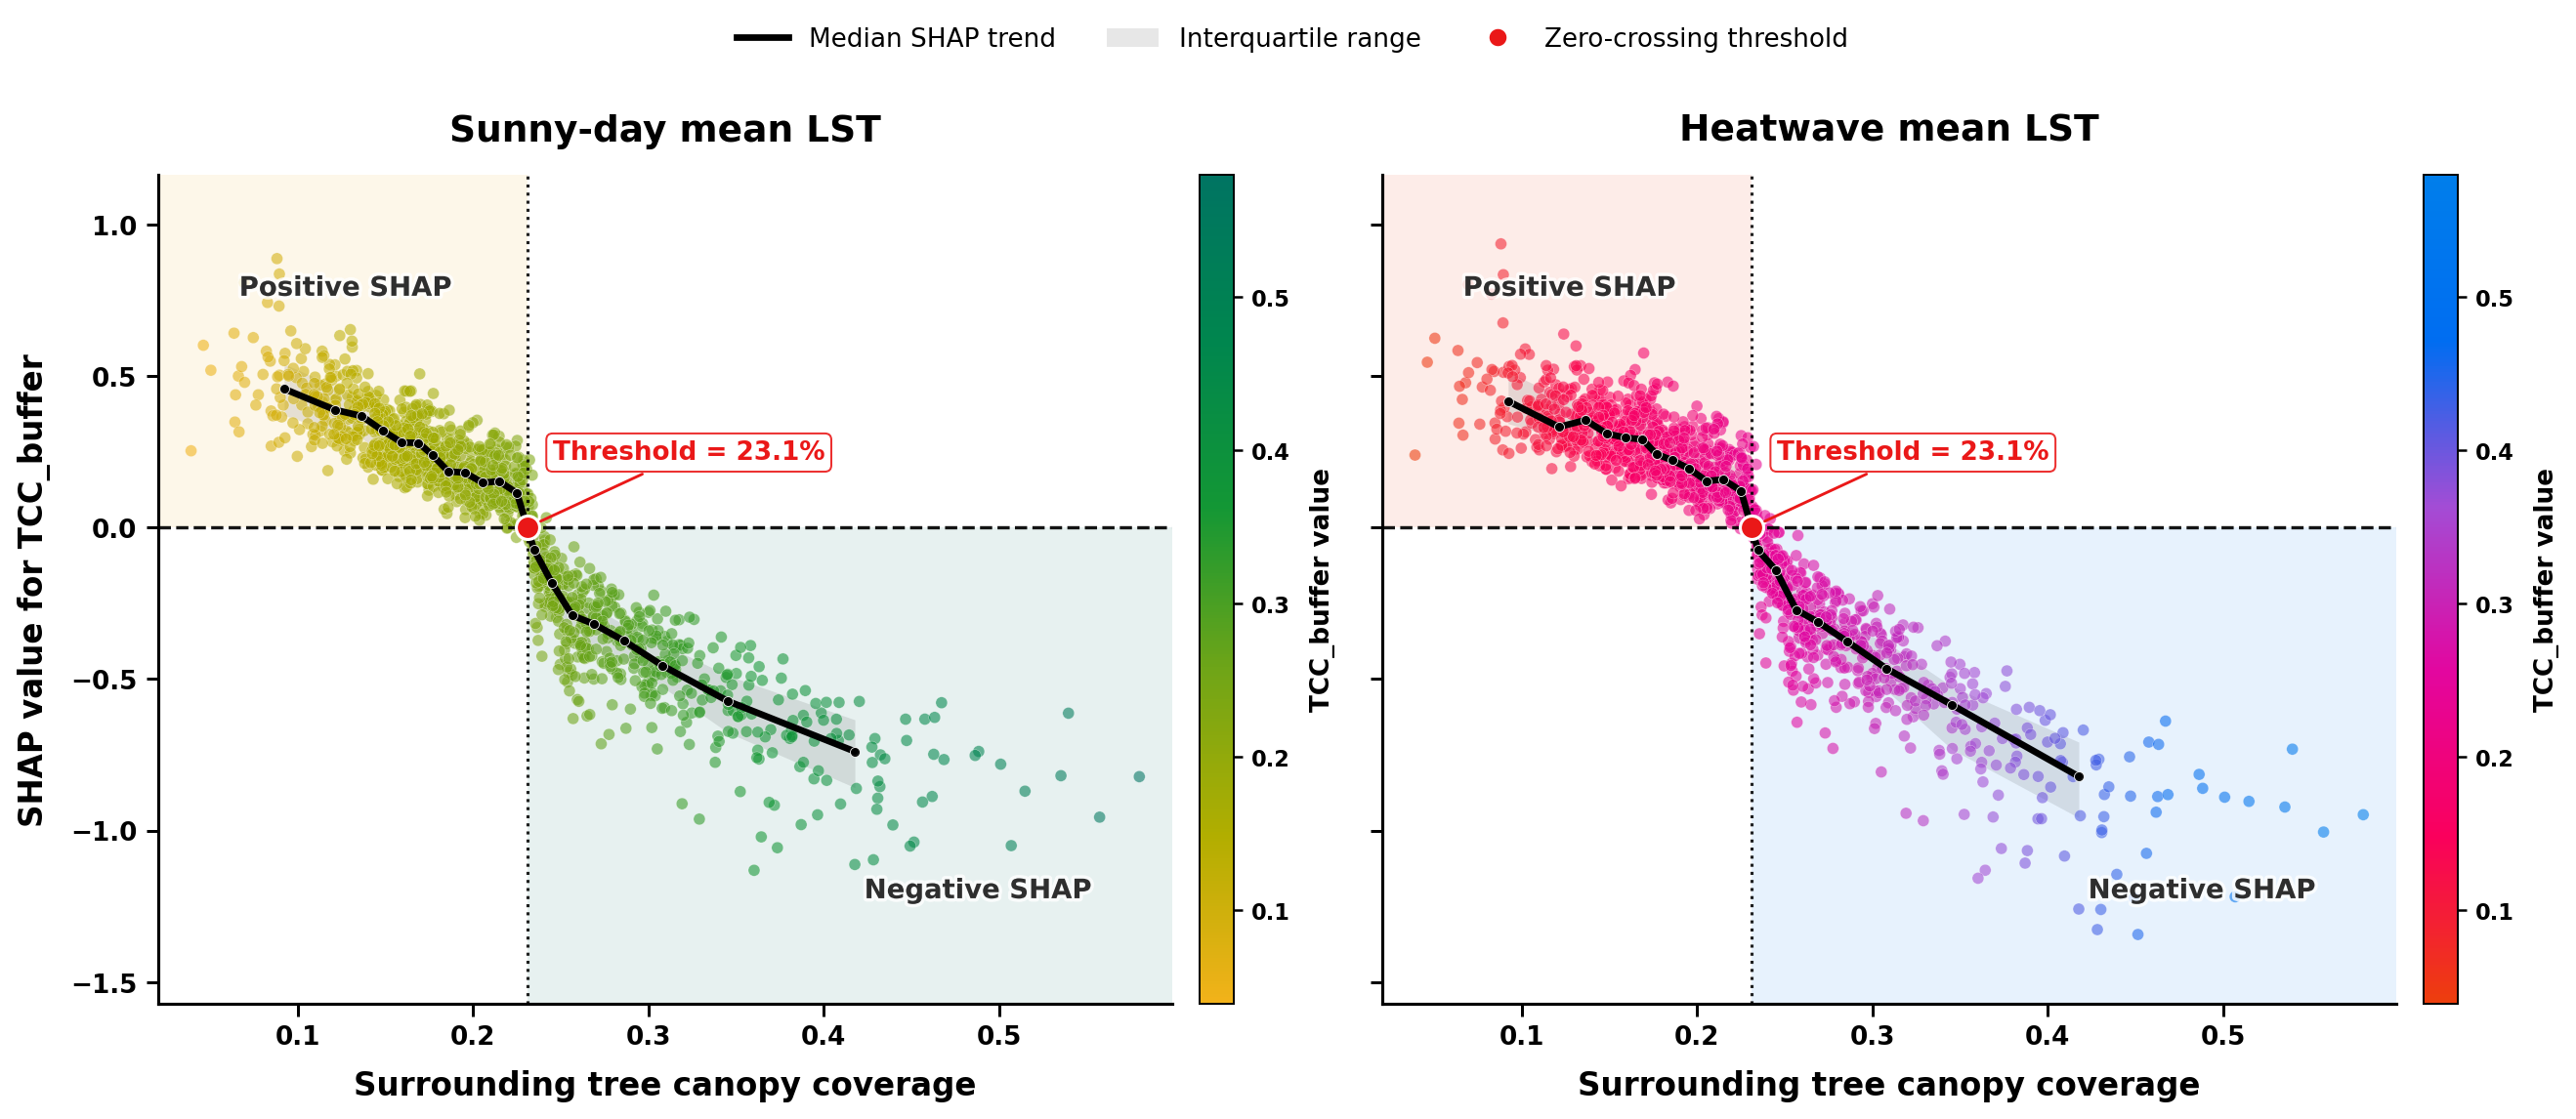


绘图完成。
PNG：E:\excel\FILES\博士申请\第二篇论文\脚本\Python\importance\TCC_buffer_SHAP_dependence_beautified.png
PDF：E:\excel\FILES\博士申请\第二篇论文\脚本\Python\importance\TCC_buffer_SHAP_dependence_beautified.pdf
原始依赖数据：E:\excel\FILES\博士申请\第二篇论文\脚本\Python\importance\TCC_buffer_SHAP_dependence_data.csv
分位数趋势数据：E:\excel\FILES\博士申请\第二篇论文\脚本\Python\importance\TCC_buffer_SHAP_dependence_trend.csv
过零阈值数据：E:\excel\FILES\博士申请\第二篇论文\脚本\Python\importance\TCC_buffer_SHAP_zero_crossing_thresholds.csv

Median SHAP trend过零结果：
 Weather  Threshold_TCC_buffer  Threshold_Percent
   SUNNY              0.230906          23.090577
HEATWAVE              0.231010          23.100958


In [1]:
# =============================================================================
# 独立Cell：美化TCC_buffer在SUNNY与HEATWAVE下的SHAP依赖图
# =============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import shap

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")


# =============================================================================
# 1. 路径与参数
# =============================================================================
DATA_PATH = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\data\wuhuanshiliang\SH_attributes.xls"
)

OUTPUT_DIR = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\脚本\Python\importance"
)

BEST_PARAMS_PATH = OUTPUT_DIR / "RF_best_parameters.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = ["SUNNY", "HEATWAVE"]

TARGET_LABEL_MAP = {
    "SUNNY": "Sunny-day mean LST",
    "HEATWAVE": "Heatwave mean LST",
}

RANDOM_STATE = 123

INDEPENDENT_VARS = [
    "TCC",
    "GCI",
    "BCI",
    "WCI",
    "RCI",
    "Shape_Area",
    "jungong",
    "BAH",
    "BHSD",
    "DIST",
    "TCC_b90m",
    "GCI_b90m",
    "BCI_b90m",
    "WCI_b90m",
    "RCI_b90m",
    "BAH_b90m",
    "BHSD_b90m",
]

DEPENDENCE_VARIABLE = "TCC_b90m"
DEPENDENCE_LABEL = "TCC_buffer"

N_QUANTILE_BINS = 20

# 当原始变量是0—1比例时，阈值标签按百分比显示
SHOW_X_AS_PERCENT = True


# =============================================================================
# 2. 配色方案
# =============================================================================

# 晴天：橙黄—绿色
SUNNY_COLORS = [
    "#F2B21A",
    "#B2AE00",
    "#70A517",
    "#139735",
    "#00864E",
    "#007462",
]

# 热浪：红—粉—紫—蓝
HEATWAVE_COLORS = [
    "#ED3E0D",
    "#FA005C",
    "#E3069F",
    "#A34CD5",
    "#006DF1",
    "#007EEB",
]

CMAP_MAP = {
    "SUNNY": LinearSegmentedColormap.from_list(
        "sunny_orange_green",
        SUNNY_COLORS,
        N=256,
    ),
    "HEATWAVE": LinearSegmentedColormap.from_list(
        "heatwave_red_purple_blue",
        HEATWAVE_COLORS,
        N=256,
    ),
}

# 背景区域使用的低值端和高值端颜色
BACKGROUND_LOW_COLOR = {
    "SUNNY": SUNNY_COLORS[0],
    "HEATWAVE": HEATWAVE_COLORS[0],
}

BACKGROUND_HIGH_COLOR = {
    "SUNNY": SUNNY_COLORS[-1],
    "HEATWAVE": HEATWAVE_COLORS[-1],
}

THRESHOLD_COLOR = "#EA1818"


# =============================================================================
# 3. SHAP值提取函数
# =============================================================================
def extract_shap_values(
    explainer,
    X_array: np.ndarray,
) -> np.ndarray:
    """
    兼容不同SHAP版本，返回二维SHAP矩阵：
    行对应样本，列对应变量。
    """

    explanation = explainer(X_array)
    values = explanation.values

    if values.ndim == 2:
        return values

    if values.ndim == 3 and values.shape[-1] == 1:
        return values[:, :, 0]

    raise ValueError(
        f"无法识别SHAP矩阵维度：{values.shape}"
    )


# =============================================================================
# 4. 读取原始数据和最佳参数
# =============================================================================
df = pd.read_excel(
    DATA_PATH,
    sheet_name=0,
    engine="xlrd",
)

best_params_df = pd.read_csv(
    BEST_PARAMS_PATH,
    encoding="utf-8-sig",
)

required_columns = TARGETS + INDEPENDENT_VARS

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise KeyError(
        "原始数据缺少以下字段：\n"
        + "\n".join(missing_columns)
    )

if DEPENDENCE_VARIABLE not in INDEPENDENT_VARS:
    raise KeyError(
        f"{DEPENDENCE_VARIABLE}不在自变量列表中。"
    )

variable_index = INDEPENDENT_VARS.index(
    DEPENDENCE_VARIABLE
)

print("数据读取完成：", df.shape)
print("\n最佳参数：")
print(best_params_df.to_string(index=False))


# =============================================================================
# 5. 使用最佳参数重新建立解释模型并计算SHAP
# =============================================================================
dependence_results = {}

for target in TARGETS:

    print("\n" + "=" * 72)
    print(f"计算 {target} 的TCC_buffer SHAP依赖数据")
    print("=" * 72)

    selected = df[
        [target] + INDEPENDENT_VARS
    ].copy()

    selected = selected.apply(
        pd.to_numeric,
        errors="coerce",
    )

    selected.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True,
    )

    # 因变量中的0视为缺失
    selected.loc[
        selected[target] == 0,
        target,
    ] = np.nan

    selected = selected.dropna(
        subset=[target] + INDEPENDENT_VARS
    ).copy()

    X = selected[INDEPENDENT_VARS].copy()
    y = selected[target].astype(float).copy()

    target_params = best_params_df.loc[
        best_params_df["LST"] == target
    ]

    if target_params.empty:
        raise ValueError(
            f"最佳参数文件中找不到{target}模型。"
        )

    target_params = target_params.iloc[0]

    best_ntree = int(
        target_params["ntree"]
    )

    best_mtry = int(
        target_params["mtry"]
    )

    best_min_node_size = int(
        target_params["min.node.size"]
    )

    print(f"有效样本数：{len(y)}")
    print(f"ntree：{best_ntree}")
    print(f"mtry：{best_mtry}")
    print(
        f"min.node.size："
        f"{best_min_node_size}"
    )

    final_rf = RandomForestRegressor(
        n_estimators=best_ntree,
        max_features=best_mtry,
        min_samples_leaf=best_min_node_size,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    final_rf.fit(X, y)

    explainer = shap.TreeExplainer(
        final_rf
    )

    X_array = X.to_numpy(
        dtype=float
    )

    shap_values = extract_shap_values(
        explainer,
        X_array,
    )

    x_values = X[
        DEPENDENCE_VARIABLE
    ].to_numpy(dtype=float)

    tcc_shap_values = shap_values[
        :,
        variable_index,
    ]

    result_df = pd.DataFrame(
        {
            "Weather": target,
            DEPENDENCE_LABEL: x_values,
            "SHAP": tcc_shap_values,
            "Original_Index": selected.index,
        }
    )

    result_df = (
        result_df
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna(
            subset=[
                DEPENDENCE_LABEL,
                "SHAP",
            ]
        )
    )

    dependence_results[target] = (
        result_df
    )

    print(
        f"{target} SHAP依赖数据："
        f"{len(result_df)}个样本"
    )


# =============================================================================
# 6. 计算分位数中位趋势与四分位距
# =============================================================================
def calculate_quantile_trend(
    data: pd.DataFrame,
    n_bins: int = 20,
) -> pd.DataFrame:
    """
    按TCC_buffer进行等频分箱。

    每个分箱计算：
    1. TCC_buffer中位数；
    2. SHAP中位数；
    3. SHAP第25百分位；
    4. SHAP第75百分位；
    5. 样本数量。
    """

    temp = data.copy()

    temp["Bin"] = pd.qcut(
        temp[DEPENDENCE_LABEL],
        q=n_bins,
        duplicates="drop",
    )

    trend = (
        temp
        .groupby(
            "Bin",
            observed=True,
        )
        .agg(
            TCC_buffer_median=(
                DEPENDENCE_LABEL,
                "median",
            ),
            SHAP_median=(
                "SHAP",
                "median",
            ),
            SHAP_q25=(
                "SHAP",
                lambda x: x.quantile(
                    0.25
                ),
            ),
            SHAP_q75=(
                "SHAP",
                lambda x: x.quantile(
                    0.75
                ),
            ),
            Sample_Size=(
                "SHAP",
                "size",
            ),
        )
        .reset_index(drop=True)
        .sort_values(
            "TCC_buffer_median"
        )
    )

    return trend


trend_results = {}

for target in TARGETS:
    trend_results[target] = (
        calculate_quantile_trend(
            dependence_results[target],
            n_bins=N_QUANTILE_BINS,
        )
    )


# =============================================================================
# 7. 识别Median SHAP Trend与y=0的交点
# =============================================================================
def find_zero_crossing(
    trend_df: pd.DataFrame,
):
    """
    寻找中位SHAP趋势线由正值转为非正值的第一个交点。

    使用相邻两个分箱中位趋势点进行线性插值：

        x0 = x1 + (0-y1)*(x2-x1)/(y2-y1)

    优先寻找：
        SHAP_i > 0 且 SHAP_(i+1) <= 0

    如果不存在正到负的交点，则寻找任意符号变化。
    如果完全不存在符号变化，返回None。
    """

    x = trend_df[
        "TCC_buffer_median"
    ].to_numpy(dtype=float)

    y = trend_df[
        "SHAP_median"
    ].to_numpy(dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return None

    # 优先识别由正转负的交点
    candidate_indices = [
        i
        for i in range(len(y) - 1)
        if y[i] > 0 and y[i + 1] <= 0
    ]

    # 如果不存在正转负，则识别任意过零
    if not candidate_indices:
        candidate_indices = [
            i
            for i in range(len(y) - 1)
            if (
                y[i] == 0
                or y[i + 1] == 0
                or y[i] * y[i + 1] < 0
            )
        ]

    if not candidate_indices:
        return None

    i = candidate_indices[0]

    x1 = x[i]
    x2 = x[i + 1]
    y1 = y[i]
    y2 = y[i + 1]

    if np.isclose(y1, 0):
        return float(x1)

    if np.isclose(y2, 0):
        return float(x2)

    if np.isclose(y2, y1):
        return float(
            (x1 + x2) / 2
        )

    x_cross = (
        x1
        + (0.0 - y1)
        * (x2 - x1)
        / (y2 - y1)
    )

    return float(x_cross)


threshold_results = {}

for target in TARGETS:

    threshold_x = find_zero_crossing(
        trend_results[target]
    )

    threshold_results[target] = (
        threshold_x
    )

    if threshold_x is None:
        print(
            f"{target}："
            "Median SHAP trend未发现明确过零交点。"
        )
    else:
        print(
            f"{target}："
            f"过零阈值约为 "
            f"{threshold_x:.4f}"
        )


# =============================================================================
# 8. 统一坐标轴范围
# =============================================================================
all_x = np.concatenate(
    [
        dependence_results[target][
            DEPENDENCE_LABEL
        ].to_numpy()
        for target in TARGETS
    ]
)

all_y = np.concatenate(
    [
        dependence_results[target][
            "SHAP"
        ].to_numpy()
        for target in TARGETS
    ]
)

x_min = np.nanmin(all_x)
x_max = np.nanmax(all_x)

y_min = np.nanmin(all_y)
y_max = np.nanmax(all_y)

x_padding = max(
    (x_max - x_min) * 0.035,
    1e-6,
)

y_padding = max(
    (y_max - y_min) * 0.10,
    1e-6,
)

common_xlim = (
    x_min - x_padding,
    x_max + x_padding,
)

common_ylim = (
    y_min - y_padding,
    y_max + y_padding,
)

# 确保y=0位于绘图区中
common_ylim = (
    min(common_ylim[0], -0.05),
    max(common_ylim[1], 0.05),
)


# =============================================================================
# 9. 辅助函数：格式化阈值标签
# =============================================================================
def format_threshold_value(
    value: float,
) -> str:
    """根据变量表达形式格式化阈值。"""

    if SHOW_X_AS_PERCENT:
        return f"{value * 100:.1f}%"

    return f"{value:.3f}"


# =============================================================================
# 10. 辅助函数：绘制正负背景区域
# =============================================================================
def add_threshold_background(
    ax,
    threshold_x,
    target,
    x_limits,
    y_limits,
):
    """
    以Median SHAP trend与y=0的交点作为分界点。

    对最符合预期响应关系的两个区域进行浅色填充：

    左上：
        较低TCC_buffer、Positive SHAP

    右下：
        较高TCC_buffer、Negative SHAP
    """

    if threshold_x is None:
        return

    x_left, x_right = x_limits
    y_bottom, y_top = y_limits

    low_color = (
        BACKGROUND_LOW_COLOR[target]
    )

    high_color = (
        BACKGROUND_HIGH_COLOR[target]
    )

    # 左上：低树冠覆盖率与正SHAP贡献
    ax.fill_between(
        [x_left, threshold_x],
        0,
        y_top,
        color=low_color,
        alpha=0.095,
        linewidth=0,
        zorder=0,
    )

    # 右下：高树冠覆盖率与负SHAP贡献
    ax.fill_between(
        [threshold_x, x_right],
        y_bottom,
        0,
        color=high_color,
        alpha=0.095,
        linewidth=0,
        zorder=0,
    )


# =============================================================================
# 11. 绘制美化后的SHAP依赖图
# =============================================================================
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14.8, 6.3),
    dpi=180,
    sharex=True,
    sharey=True,
)

for ax, target in zip(
    axes,
    TARGETS,
):

    plot_df = dependence_results[
        target
    ]

    trend_df = trend_results[
        target
    ]

    threshold_x = threshold_results[
        target
    ]

    cmap = CMAP_MAP[target]

    # ---------------------------------------------------------
    # 统一散点颜色映射范围
    # ---------------------------------------------------------
    norm = Normalize(
        vmin=x_min,
        vmax=x_max,
    )

    # ---------------------------------------------------------
    # 背景区域
    # ---------------------------------------------------------
    add_threshold_background(
        ax=ax,
        threshold_x=threshold_x,
        target=target,
        x_limits=common_xlim,
        y_limits=common_ylim,
    )

    # ---------------------------------------------------------
    # 原始SHAP散点
    # ---------------------------------------------------------
    scatter = ax.scatter(
        plot_df[DEPENDENCE_LABEL],
        plot_df["SHAP"],
        c=plot_df[DEPENDENCE_LABEL],
        cmap=cmap,
        norm=norm,
        s=23,
        alpha=0.58,
        edgecolors="white",
        linewidths=0.18,
        rasterized=True,
        zorder=3,
    )

    # ---------------------------------------------------------
    # 四分位距区域
    # ---------------------------------------------------------
    ax.fill_between(
        trend_df[
            "TCC_buffer_median"
        ].to_numpy(dtype=float),
        trend_df[
            "SHAP_q25"
        ].to_numpy(dtype=float),
        trend_df[
            "SHAP_q75"
        ].to_numpy(dtype=float),
        color="black",
        alpha=0.095,
        linewidth=0,
        label="Interquartile range",
        zorder=2,
    )

    # ---------------------------------------------------------
    # Median SHAP trend
    # ---------------------------------------------------------
    ax.plot(
        trend_df[
            "TCC_buffer_median"
        ],
        trend_df[
            "SHAP_median"
        ],
        color="black",
        linewidth=2.7,
        solid_capstyle="round",
        label="Median SHAP trend",
        zorder=5,
    )

    # 趋势节点，可根据需要注释掉
    ax.scatter(
        trend_df[
            "TCC_buffer_median"
        ],
        trend_df[
            "SHAP_median"
        ],
        s=16,
        facecolor="black",
        edgecolor="white",
        linewidth=0.35,
        alpha=0.92,
        zorder=6,
    )

    # ---------------------------------------------------------
    # y=0参考线
    # ---------------------------------------------------------
    ax.axhline(
        y=0,
        color="black",
        linestyle="--",
        linewidth=1.35,
        alpha=0.92,
        zorder=4,
    )

    # ---------------------------------------------------------
    # 阈值交点、竖线和标签
    # ---------------------------------------------------------
    if threshold_x is not None:

        ax.axvline(
            x=threshold_x,
            color="black",
            linestyle=":",
            linewidth=1.25,
            alpha=0.88,
            zorder=4,
        )

        ax.scatter(
            threshold_x,
            0,
            s=92,
            facecolor=THRESHOLD_COLOR,
            edgecolor="white",
            linewidth=1.25,
            zorder=8,
        )

        threshold_label = (
            format_threshold_value(
                threshold_x
            )
        )

        annotation_y_offset = (
            common_ylim[1]
            - common_ylim[0]
        ) * 0.075

        annotation_x_offset = (
            common_xlim[1]
            - common_xlim[0]
        ) * 0.025

        # 根据阈值位置自动决定文字放置方向
        if threshold_x <= (
            common_xlim[0]
            + common_xlim[1]
        ) / 2:
            text_x = (
                threshold_x
                + annotation_x_offset
            )
            horizontal_alignment = "left"
        else:
            text_x = (
                threshold_x
                - annotation_x_offset
            )
            horizontal_alignment = "right"

        ax.annotate(
            f"Threshold = {threshold_label}",
            xy=(threshold_x, 0),
            xytext=(
                text_x,
                annotation_y_offset,
            ),
            ha=horizontal_alignment,
            va="bottom",
            fontsize=10.5,
            fontweight="bold",
            color=THRESHOLD_COLOR,
            arrowprops={
                "arrowstyle": "-",
                "color": THRESHOLD_COLOR,
                "linewidth": 1.15,
                "shrinkA": 2,
                "shrinkB": 6,
            },
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": THRESHOLD_COLOR,
                "linewidth": 0.8,
                "alpha": 0.90,
            },
            zorder=9,
        )

    # ---------------------------------------------------------
    # Positive与Negative标注
    # ---------------------------------------------------------
    x_range = (
        common_xlim[1]
        - common_xlim[0]
    )

    y_range = (
        common_ylim[1]
        - common_ylim[0]
    )

    if threshold_x is not None:

        positive_x = (
            common_xlim[0]
            + 0.08 * x_range
        )

        negative_x = (
            common_xlim[1]
            - 0.08 * x_range
        )

    else:

        positive_x = (
            common_xlim[0]
            + 0.10 * x_range
        )

        negative_x = (
            common_xlim[1]
            - 0.10 * x_range
        )

    positive_y = (
        common_ylim[1]
        - 0.12 * y_range
    )

    negative_y = (
        common_ylim[0]
        + 0.12 * y_range
    )

    positive_text = ax.text(
        positive_x,
        positive_y,
        "Positive SHAP",
        ha="left",
        va="top",
        fontsize=11,
        fontweight="bold",
        color="black",
        alpha=0.78,
        zorder=10,
    )

    negative_text = ax.text(
        negative_x,
        negative_y,
        "Negative SHAP",
        ha="right",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="black",
        alpha=0.78,
        zorder=10,
    )

    # 白色描边，避免文字与散点重叠后不可读
    for text_object in [
        positive_text,
        negative_text,
    ]:
        text_object.set_path_effects(
            [
                pe.withStroke(
                    linewidth=2.8,
                    foreground="white",
                )
            ]
        )

    # ---------------------------------------------------------
    # 坐标范围、标题与标签
    # ---------------------------------------------------------
    ax.set_xlim(common_xlim)
    ax.set_ylim(common_ylim)

    ax.set_xlabel(
        "Surrounding tree canopy coverage",
        fontsize=13,
        fontweight="bold",
        labelpad=8,
    )

    ax.set_title(
        TARGET_LABEL_MAP[target],
        fontsize=15,
        fontweight="bold",
        pad=14,
    )

    ax.tick_params(
        axis="both",
        labelsize=10.5,
        width=1.2,
        length=5,
        direction="out",
    )

    for tick_label in (
        ax.get_xticklabels()
        + ax.get_yticklabels()
    ):
        tick_label.set_fontweight(
            "bold"
        )

    # ---------------------------------------------------------
    # 坐标轴样式
    # ---------------------------------------------------------
    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )

    ax.spines["left"].set_linewidth(
        1.25
    )

    ax.spines["bottom"].set_linewidth(
        1.25
    )

    ax.grid(False)

    # ---------------------------------------------------------
    # 每个子图独立色带
    # ---------------------------------------------------------
    sm = ScalarMappable(
        norm=norm,
        cmap=cmap,
    )

    sm.set_array([])

    colorbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="vertical",
        fraction=0.041,
        pad=0.025,
        aspect=24,
    )

    colorbar.set_label(
        "TCC_buffer value",
        fontsize=10.5,
        fontweight="bold",
        labelpad=8,
    )

    colorbar.ax.tick_params(
        labelsize=9,
        width=1.0,
    )

    for tick_label in (
        colorbar.ax.get_yticklabels()
    ):
        tick_label.set_fontweight(
            "bold"
        )

    colorbar.outline.set_linewidth(
        0.8
    )


axes[0].set_ylabel(
    "SHAP value for TCC_buffer",
    fontsize=13,
    fontweight="bold",
    labelpad=8,
)


# =============================================================================
# 12. 公共图例
# =============================================================================
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2.7,
        label="Median SHAP trend",
    ),
    Patch(
        facecolor="black",
        alpha=0.095,
        edgecolor="none",
        label="Interquartile range",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=THRESHOLD_COLOR,
        markeredgecolor="white",
        markeredgewidth=1.0,
        markersize=8,
        label="Zero-crossing threshold",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.015),
    ncol=3,
    frameon=False,
    fontsize=10.5,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.94]
)


# =============================================================================
# 13. 保存图件
# =============================================================================
png_path = (
    OUTPUT_DIR
    / "TCC_buffer_SHAP_dependence_beautified.png"
)

pdf_path = (
    OUTPUT_DIR
    / "TCC_buffer_SHAP_dependence_beautified.pdf"
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(fig)


# =============================================================================
# 14. 输出依赖数据、趋势数据和阈值结果
# =============================================================================
dependence_all_df = pd.concat(
    [
        dependence_results[
            "SUNNY"
        ],
        dependence_results[
            "HEATWAVE"
        ],
    ],
    ignore_index=True,
)

trend_all_df = pd.concat(
    [
        trend_results[
            "SUNNY"
        ].assign(
            Weather="SUNNY"
        ),
        trend_results[
            "HEATWAVE"
        ].assign(
            Weather="HEATWAVE"
        ),
    ],
    ignore_index=True,
)

threshold_df = pd.DataFrame(
    {
        "Weather": TARGETS,
        "Threshold_TCC_buffer": [
            threshold_results[target]
            for target in TARGETS
        ],
    }
)

threshold_df[
    "Threshold_Percent"
] = (
    threshold_df[
        "Threshold_TCC_buffer"
    ]
    * 100
)

dependence_data_path = (
    OUTPUT_DIR
    / "TCC_buffer_SHAP_dependence_data.csv"
)

trend_data_path = (
    OUTPUT_DIR
    / "TCC_buffer_SHAP_dependence_trend.csv"
)

threshold_data_path = (
    OUTPUT_DIR
    / "TCC_buffer_SHAP_zero_crossing_thresholds.csv"
)

dependence_all_df.to_csv(
    dependence_data_path,
    index=False,
    encoding="utf-8-sig",
)

trend_all_df.to_csv(
    trend_data_path,
    index=False,
    encoding="utf-8-sig",
)

threshold_df.to_csv(
    threshold_data_path,
    index=False,
    encoding="utf-8-sig",
)


# =============================================================================
# 15. 输出运行结果
# =============================================================================
print("\n绘图完成。")
print(f"PNG：{png_path}")
print(f"PDF：{pdf_path}")
print(f"原始依赖数据：{dependence_data_path}")
print(f"分位数趋势数据：{trend_data_path}")
print(f"过零阈值数据：{threshold_data_path}")

print("\nMedian SHAP trend过零结果：")
print(
    threshold_df.to_string(
        index=False
    )
)

In [1]:
# -*- coding: utf-8 -*-
"""
Random Forest 正式建模：SUNNY与HEATWAVE平均LST（90 m缓冲区）

主要步骤
--------
1. 对SUNNY与HEATWAVE分别删除 LST=0 和 LST 缺失样本；
2. 按70%训练集、30%测试集划分数据；
3. 仅在训练集内使用 RandomizedSearchCV + 5折交叉验证调参；
4. 搜索最佳 ntree、mtry、min.node.size；
5. 使用最佳模型计算训练集与独立测试集 R²、RMSE；
6. 使用最佳参数在全部完整案例样本上重建解释模型；
7. 通过 shap.TreeExplainer 计算 Random Forest TreeSHAP；
8. 输出参数、性能、预测结果、SHAP重要性以及图件；
9. 为不同天气情景设置不同的SHAP摘要图色带：
   - SUNNY：低值绿色，高值黄色；
   - HEATWAVE：低值紫色，高值红色。

参数名称对应关系
----------------
ntree         -> sklearn: n_estimators
mtry          -> sklearn: max_features
min.node.size -> sklearn: min_samples_leaf

首次运行如缺少依赖，请在Jupyter Notebook中执行：
!pip install pandas numpy scipy scikit-learn matplotlib shap openpyxl xlrd
"""

# =============================================================================
# 0. 导入库
# =============================================================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import shap

from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import (
    RandomizedSearchCV,
    train_test_split,
)

warnings.filterwarnings("ignore")


# =============================================================================
# 1. 文件路径与基础参数
# =============================================================================
DATA_PATH = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\data\wuhuanshiliang\SH_attributes.xls"
)

OUTPUT_DIR = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\脚本\Python\importance"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


TARGETS = [
    "SUNNY",
    "HEATWAVE",
]


TARGET_LABEL_MAP = {
    "SUNNY": "Sunny-day mean LST",
    "HEATWAVE": "Heatwave mean LST",
}


RANDOM_STATE = 123

# 训练集:测试集 = 70:30
TEST_SIZE = 0.30

# 随机搜索次数与交叉验证折数
N_ITER_SEARCH = 50
CV_FOLDS = 5


# =============================================================================
# 1.1 SHAP摘要图颜色映射
# =============================================================================
# Matplotlib色带顺序：
# 第一个颜色 = Low value
# 最后一个颜色 = High value

SUNNY_SHAP_CMAP = LinearSegmentedColormap.from_list(
    "sunny_shap_cmap",
    [
        "#2E7D32",  # Low value：绿色
        "#FDD835",  # High value：黄色
    ],
)

HEATWAVE_SHAP_CMAP = LinearSegmentedColormap.from_list(
    "heatwave_shap_cmap",
    [
        "#6A1B9A",  # Low value：紫色
        "#E53935",  # High value：红色
    ],
)


# =============================================================================
# 1.2 自变量设置
# =============================================================================
# 90 m模型的固定变量
FIXED_VARS = [
    "TCC",
    "GCI",
    "BCI",
    "WCI",
    "RCI",
    "Shape_Area",
    "jungong",
    "BAH",
    "BHSD",
    "DIST",
]

# 90 m缓冲区变量
BUFFER_VARS_90M = [
    "TCC_b90m",
    "GCI_b90m",
    "BCI_b90m",
    "WCI_b90m",
    "RCI_b90m",
    "BAH_b90m",
    "BHSD_b90m",
]

INDEPENDENT_VARS = FIXED_VARS + BUFFER_VARS_90M


# 变量显示名称
VAR_NAME_MAP = {
    "TCC": "TCC",
    "GCI": "GCI",
    "BCI": "BCI",
    "WCI": "WCI",
    "RCI": "RCI",
    "Shape_Area": "Area",
    "jungong": "CY",
    "BAH": "BAH",
    "BHSD": "BHSD",
    "DIST": "DIST",
    "TCC_b90m": "TCC_buffer",
    "GCI_b90m": "GCI_buffer",
    "BCI_b90m": "BCI_buffer",
    "WCI_b90m": "WCI_buffer",
    "RCI_b90m": "RCI_buffer",
    "BAH_b90m": "BAH_buffer",
    "BHSD_b90m": "BHSD_buffer",
}

DISPLAY_VARS = [
    VAR_NAME_MAP[v]
    for v in INDEPENDENT_VARS
]


# =============================================================================
# 2. 工具函数
# =============================================================================
def get_shap_colormap(
    target: str,
) -> LinearSegmentedColormap:
    """
    根据天气情景返回SHAP摘要图色带。

    SUNNY：
    Low value = 绿色
    High value = 黄色

    HEATWAVE：
    Low value = 紫色
    High value = 红色
    """
    if target == "SUNNY":
        return SUNNY_SHAP_CMAP

    if target == "HEATWAVE":
        return HEATWAVE_SHAP_CMAP

    raise ValueError(
        f"未定义目标情景 {target} 对应的SHAP颜色映射。"
    )


def validate_columns(
    df: pd.DataFrame,
) -> None:
    """检查建模所需字段是否全部存在。"""
    required = set(
        TARGETS + INDEPENDENT_VARS
    )

    missing = sorted(
        required.difference(df.columns)
    )

    if missing:
        raise KeyError(
            "数据中缺少以下必要字段：\n"
            + "\n".join(missing)
        )


def prepare_target_data(
    df: pd.DataFrame,
    target: str,
) -> tuple[pd.DataFrame, pd.Series, pd.Index]:
    """
    为一个因变量准备数据。

    处理规则：
    1. 所有建模字段转换为数值；
    2. 正负无穷转为NaN；
    3. 因变量等于0时按缺失值处理；
    4. 删除因变量或任一自变量存在缺失值的整行；
    5. 不进行任何缺失值填补。
    """
    selected = df[
        [target] + INDEPENDENT_VARS
    ].copy()

    selected = selected.apply(
        pd.to_numeric,
        errors="coerce",
    )

    selected.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True,
    )

    # LST=0表示缺失
    selected.loc[
        selected[target] == 0,
        target,
    ] = np.nan

    n_before_drop = len(selected)

    selected = selected.dropna(
        subset=[target] + INDEPENDENT_VARS
    ).copy()

    n_removed = (
        n_before_drop
        - len(selected)
    )

    print(
        f"{target}: 因变量或自变量缺失共删除 {n_removed} 行，"
        f"保留 {len(selected)} 行完整案例。"
    )

    if len(selected) < 50:
        raise ValueError(
            f"{target} 仅有 {len(selected)} 个有效样本，"
            "不建议进行当前建模。"
        )

    X = selected[
        INDEPENDENT_VARS
    ].copy()

    y = selected[
        target
    ].astype(float).copy()

    original_index = (
        selected.index.copy()
    )

    return X, y, original_index


def build_search() -> RandomizedSearchCV:
    """
    构建随机森林随机调参对象。

    数据在进入该函数前已经完成完整案例删除，
    因此这里不进行任何缺失值填补。
    五折交叉验证仅在训练集内部执行。
    """
    rf = RandomForestRegressor(
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    n_features = len(
        INDEPENDENT_VARS
    )

    param_distributions = {
        # ntree：500–2000
        "n_estimators": randint(
            500,
            2001,
        ),

        # mtry：3–全部变量
        "max_features": randint(
            3,
            n_features + 1,
        ),

        # min.node.size：1–15
        "min_samples_leaf": randint(
            1,
            16,
        ),
    }

    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_distributions,
        n_iter=N_ITER_SEARCH,
        scoring="neg_root_mean_squared_error",
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
        refit=True,
    )

    return search


def calculate_metrics(
    y_true: pd.Series | np.ndarray,
    y_pred: np.ndarray,
) -> tuple[float, float]:
    """计算R²与RMSE。"""
    r2 = r2_score(
        y_true,
        y_pred,
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred,
        )
    )

    return float(r2), float(rmse)


def extract_shap_values(
    explainer: shap.TreeExplainer,
    X_array: np.ndarray,
) -> np.ndarray:
    """
    兼容不同SHAP版本，提取二维回归SHAP矩阵。
    """
    explanation = explainer(
        X_array
    )

    values = explanation.values

    # 一般RF回归结果：
    # n_samples × n_features
    if values.ndim == 2:
        return values

    # 某些版本可能额外返回输出维度
    if (
        values.ndim == 3
        and values.shape[-1] == 1
    ):
        return values[:, :, 0]

    raise ValueError(
        f"无法识别SHAP矩阵维度：{values.shape}"
    )


# =============================================================================
# 2.1 单独的Mean |SHAP|变量重要性图
# =============================================================================
def save_shap_bar(
    importance_df: pd.DataFrame,
    target: str,
) -> None:
    """绘制单独的Mean |SHAP|变量重要性图。"""
    plot_df = (
        importance_df
        .sort_values(
            "MeanAbsSHAP",
            ascending=True,
        )
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(
        figsize=(8.5, 7.2),
        dpi=180,
    )

    ax.barh(
        plot_df["Variable_Label"],
        plot_df["MeanAbsSHAP"],
        color="lightpink",
        alpha=0.60,
        edgecolor="black",
        linewidth=0.6,
    )

    max_value = (
        plot_df["MeanAbsSHAP"]
        .max()
    )

    for i, row in plot_df.iterrows():
        ax.text(
            row["MeanAbsSHAP"]
            + max_value * 0.015,
            i,
            (
                f'{row["MeanAbsSHAP"]:.2f} '
                f'({row["RelativeImportance_percent"]:.1f}%)'
            ),
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
        )

    ax.set_xlabel(
        "Mean |SHAP Value|",
        fontsize=14,
        fontweight="bold",
    )

    ax.set_ylabel("")

    ax.set_title(
        TARGET_LABEL_MAP.get(
            target,
            target,
        ),
        fontsize=16,
        fontweight="bold",
    )

    ax.tick_params(
        axis="both",
        labelsize=11,
        width=1.2,
        direction="out",
    )

    for label in (
        ax.get_xticklabels()
        + ax.get_yticklabels()
    ):
        label.set_fontweight("bold")

    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )

    ax.spines["left"].set_linewidth(
        1.2
    )

    ax.spines["bottom"].set_linewidth(
        1.2
    )

    ax.grid(False)

    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR
        / f"{target}_RF_SHAP_importance.png",
        dpi=600,
        bbox_inches="tight",
    )

    fig.savefig(
        OUTPUT_DIR
        / f"{target}_RF_SHAP_importance.pdf",
        bbox_inches="tight",
    )

    plt.close(fig)


# =============================================================================
# 2.2 单独的SHAP摘要蜂群图
# =============================================================================
def save_shap_beeswarm(
    shap_values: np.ndarray,
    X_display: pd.DataFrame,
    target: str,
) -> None:
    """
    绘制单独的SHAP摘要蜂群图。

    SUNNY：
    低变量值为绿色，高变量值为黄色。

    HEATWAVE：
    低变量值为紫色，高变量值为红色。
    """
    expl = shap.Explanation(
        values=shap_values,
        data=X_display.values,
        feature_names=X_display.columns.tolist(),
    )

    shap_cmap = get_shap_colormap(
        target
    )

    fig, ax = plt.subplots(
        figsize=(9.5, 7.2),
        dpi=180,
    )

    shap.plots.beeswarm(
        expl,
        ax=ax,
        show=False,
        plot_size=None,
        max_display=X_display.shape[1],
        color=shap_cmap,
    )

    # 设置蜂群点透明度
    for collection in ax.collections:
        collection.set_alpha(
            0.70
        )

    ax.set_xlabel(
        "SHAP Value",
        fontsize=14,
        fontweight="bold",
    )

    ax.set_title(
        TARGET_LABEL_MAP.get(
            target,
            target,
        ),
        fontsize=16,
        fontweight="bold",
    )

    ax.tick_params(
        axis="both",
        labelsize=11,
        width=1.2,
        direction="out",
    )

    for label in (
        ax.get_xticklabels()
        + ax.get_yticklabels()
    ):
        label.set_fontweight(
            "bold"
        )

    ax.grid(False)

    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR
        / f"{target}_RF_SHAP_beeswarm.png",
        dpi=600,
        bbox_inches="tight",
    )

    fig.savefig(
        OUTPUT_DIR
        / f"{target}_RF_SHAP_beeswarm.pdf",
        bbox_inches="tight",
    )

    plt.close(fig)


# =============================================================================
# 2.3 Mean(|SHAP|)柱状图 + SHAP beeswarm叠加图
# =============================================================================
def save_overlay_plot(
    shap_values: np.ndarray,
    X_display: pd.DataFrame,
    importance_df: pd.DataFrame,
    target: str,
) -> None:
    """
    绘制：
    Mean(|SHAP|)横向柱状图
    + SHAP beeswarm双X轴叠加图。

    SUNNY：
    低变量值为绿色，高变量值为黄色。

    HEATWAVE：
    低变量值为紫色，高变量值为红色。
    """
    plot_df = (
        importance_df
        .sort_values(
            "MeanAbsSHAP",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    ordered_vars = (
        plot_df["Variable"]
        .tolist()
    )

    ordered_labels = (
        plot_df["Variable_Label"]
        .tolist()
    )

    ordered_indices = [
        INDEPENDENT_VARS.index(v)
        for v in ordered_vars
    ]

    shap_values_sorted = (
        shap_values[
            :,
            ordered_indices,
        ]
    )

    X_sorted = X_display[
        [
            VAR_NAME_MAP[v]
            for v in ordered_vars
        ]
    ].copy()

    mean_shap_sorted = (
        plot_df["MeanAbsSHAP"]
        .to_numpy()
    )

    n_feat = len(
        ordered_labels
    )

    # 根据天气情景选择色带
    shap_cmap = get_shap_colormap(
        target
    )

    # 第一个变量位于最上方
    y_pos = np.arange(
        n_feat
    )[::-1]

    fig = plt.figure(
        figsize=(11, 7),
        dpi=180,
    )

    ax_sw = fig.add_axes(
        [0.28, 0.12, 0.58, 0.76]
    )

    ax_bar = ax_sw.twiny()

    ax_bar.set_zorder(0)
    ax_sw.set_zorder(1)
    ax_sw.patch.set_alpha(0)

    # -------------------------------------------------------------------------
    # 底层：Mean(|SHAP|)柱状图
    # -------------------------------------------------------------------------
    ax_bar.barh(
        y=y_pos,
        width=mean_shap_sorted,
        height=0.65,
        color="lightpink",
        alpha=0.45,
        edgecolor="black",
        linewidth=0.5,
        zorder=0,
    )

    xlim_bar = (
        mean_shap_sorted.max()
        * 1.20
    )

    ax_bar.set_xlim(
        0,
        xlim_bar,
    )

    xticks_bar = np.linspace(
        0,
        xlim_bar,
        5,
    )

    ax_bar.set_xticks(
        xticks_bar
    )

    ax_bar.set_xticklabels(
        [
            f"{x:.2f}"
            for x in xticks_bar
        ],
        fontsize=12,
        fontweight="bold",
    )

    ax_bar.set_xlabel(
        "Mean |SHAP Value|",
        fontsize=14,
        fontweight="bold",
    )

    ax_bar.xaxis.set_label_position(
        "top"
    )

    ax_bar.xaxis.tick_top()

    ax_bar.set_yticks(
        y_pos
    )

    # -------------------------------------------------------------------------
    # 上层：SHAP beeswarm
    # -------------------------------------------------------------------------
    expl = shap.Explanation(
        values=shap_values_sorted,
        data=X_sorted.values,
        feature_names=ordered_labels,
    )

    plt.sca(ax_sw)

    shap.plots.beeswarm(
        expl,
        ax=ax_sw,
        show=False,
        plot_size=None,
        max_display=n_feat,
        color=shap_cmap,
    )

    # 设置蜂群点透明度和大小
    for collection in ax_sw.collections:
        collection.set_alpha(
            0.70
        )

        old_sizes = (
            collection.get_sizes()
        )

        if (
            old_sizes is not None
            and len(old_sizes) > 0
        ):
            collection.set_sizes(
                old_sizes * 1.0
            )

    for label in ax_sw.get_xticklabels():
        label.set_fontsize(
            12
        )
        label.set_fontweight(
            "bold"
        )

    ax_sw.set_yticks(
        y_pos
    )

    ax_sw.set_yticklabels(
        ordered_labels,
        fontsize=13,
        fontweight="bold",
    )

    ax_sw.set_xlabel(
        "SHAP Value",
        fontsize=14,
        fontweight="bold",
    )

    # -------------------------------------------------------------------------
    # 数值标签：MeanAbsSHAP + 相对重要性
    # -------------------------------------------------------------------------
    xmin, xmax = (
        ax_sw.get_xlim()
    )

    text_x = (
        xmin
        + 0.02 * (xmax - xmin)
    )

    for i, row_i in plot_df.iterrows():
        ax_sw.text(
            x=text_x,
            y=y_pos[i],
            s=(
                f'{row_i["MeanAbsSHAP"]:.2f} '
                f'({row_i["RelativeImportance_percent"]:.1f}%)'
            ),
            va="center",
            ha="left",
            fontsize=10.5,
            fontweight="bold",
            color="black",
            zorder=999,
            clip_on=False,
        )

    # -------------------------------------------------------------------------
    # 坐标轴与样式
    # -------------------------------------------------------------------------
    ax_sw.tick_params(
        axis="x",
        labelsize=12,
        width=1.2,
        direction="out",
    )

    ax_sw.tick_params(
        axis="y",
        labelsize=13,
        width=1.2,
        direction="out",
    )

    ax_bar.tick_params(
        axis="x",
        labelsize=12,
        width=1.2,
        direction="out",
    )

    ax_bar.tick_params(
        axis="y",
        length=0,
    )

    for ax in [
        ax_sw,
        ax_bar,
    ]:
        ax.spines["left"].set_linewidth(
            1.2
        )

        ax.spines["bottom"].set_linewidth(
            1.2
        )

        ax.spines["top"].set_linewidth(
            1.2
        )

        ax.spines["right"].set_visible(
            False
        )

    ax_sw.grid(False)

    ax_bar.grid(
        axis="x",
        linestyle=":",
        linewidth=0.7,
        alpha=0.45,
    )

    ax_sw.set_title(
        TARGET_LABEL_MAP.get(
            target,
            target,
        ),
        fontsize=16,
        fontweight="bold",
        pad=18,
    )

    fig.savefig(
        OUTPUT_DIR
        / f"{target}_RF_SHAP_Bar_Beeswarm_Overlay.png",
        dpi=600,
        bbox_inches="tight",
    )

    fig.savefig(
        OUTPUT_DIR
        / f"{target}_RF_SHAP_Bar_Beeswarm_Overlay.pdf",
        bbox_inches="tight",
    )

    plt.close(fig)


# =============================================================================
# 3. 主程序
# =============================================================================
def main() -> None:
    print("=" * 80)
    print("读取数据")
    print("=" * 80)

    df = pd.read_excel(
        DATA_PATH,
        sheet_name=0,
        engine="xlrd",
    )

    print(
        f"数据维度："
        f"{df.shape[0]} 行 × "
        f"{df.shape[1]} 列"
    )

    validate_columns(
        df
    )

    print(
        "字段检查通过。"
    )

    all_metrics = []
    all_best_params = []
    all_importance = []
    all_cv_results = []
    all_predictions = []

    for target in TARGETS:
        print(
            "\n"
            + "=" * 80
        )

        print(
            f"Processing: {target}"
        )

        print(
            "=" * 80
        )

        X, y, original_index = (
            prepare_target_data(
                df,
                target,
            )
        )

        print(
            f"有效样本数：{len(y)}"
        )

        print(
            f"自变量数量：{X.shape[1]}"
        )

        # ---------------------------------------------------------------------
        # 3.1 固定划分：70%训练、30%测试
        # ---------------------------------------------------------------------
        (
            X_train,
            X_test,
            y_train,
            y_test,
            idx_train,
            idx_test,
        ) = train_test_split(
            X,
            y,
            original_index,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            shuffle=True,
        )

        print(
            f"训练集样本数：{len(y_train)}"
        )

        print(
            f"测试集样本数：{len(y_test)}"
        )

        # ---------------------------------------------------------------------
        # 3.2 仅在训练集内做随机搜索 + 五折交叉验证
        # ---------------------------------------------------------------------
        search = build_search()

        search.fit(
            X_train,
            y_train,
        )

        best_pipeline = (
            search.best_estimator_
        )

        best_params_raw = (
            search.best_params_
        )

        best_ntree = int(
            best_params_raw[
                "n_estimators"
            ]
        )

        best_mtry = int(
            best_params_raw[
                "max_features"
            ]
        )

        best_min_node_size = int(
            best_params_raw[
                "min_samples_leaf"
            ]
        )

        print(
            "\n最佳超参数："
        )

        print(
            f"ntree = {best_ntree}"
        )

        print(
            f"mtry = {best_mtry}"
        )

        print(
            "min.node.size = "
            f"{best_min_node_size}"
        )

        print(
            "Best 5-fold CV RMSE = "
            f"{-search.best_score_:.4f}"
        )

        # ---------------------------------------------------------------------
        # 3.3 训练集与独立测试集性能
        # ---------------------------------------------------------------------
        pred_train = (
            best_pipeline.predict(
                X_train
            )
        )

        pred_test = (
            best_pipeline.predict(
                X_test
            )
        )

        train_r2, train_rmse = (
            calculate_metrics(
                y_train,
                pred_train,
            )
        )

        test_r2, test_rmse = (
            calculate_metrics(
                y_test,
                pred_test,
            )
        )

        print(
            "\n模型性能："
        )

        print(
            f"Train R²={train_r2:.4f}, "
            f"Train RMSE={train_rmse:.4f}"
        )

        print(
            f"Test R²={test_r2:.4f}, "
            f"Test RMSE={test_rmse:.4f}"
        )

        all_metrics.append(
            {
                "LST": target,
                "n_total": int(len(y)),
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                "train_ratio": float(
                    1 - TEST_SIZE
                ),
                "test_ratio": float(
                    TEST_SIZE
                ),
                "cv_folds": CV_FOLDS,
                "random_search_iterations": N_ITER_SEARCH,
                "best_cv_rmse": float(
                    -search.best_score_
                ),
                "train_r2": train_r2,
                "train_rmse": train_rmse,
                "test_r2": test_r2,
                "test_rmse": test_rmse,
            }
        )

        all_best_params.append(
            {
                "LST": target,
                "ntree": best_ntree,
                "mtry": best_mtry,
                "min.node.size": best_min_node_size,
                "random_state": RANDOM_STATE,
                "selection_metric": "5-fold CV RMSE",
            }
        )

        # ---------------------------------------------------------------------
        # 保存训练集和测试集预测
        # ---------------------------------------------------------------------
        pred_train_df = pd.DataFrame(
            {
                "LST": target,
                "dataset": "train",
                "original_row_index": idx_train,
                "observed": np.asarray(
                    y_train
                ),
                "predicted": pred_train,
                "residual": (
                    np.asarray(y_train)
                    - pred_train
                ),
            }
        )

        pred_test_df = pd.DataFrame(
            {
                "LST": target,
                "dataset": "test",
                "original_row_index": idx_test,
                "observed": np.asarray(
                    y_test
                ),
                "predicted": pred_test,
                "residual": (
                    np.asarray(y_test)
                    - pred_test
                ),
            }
        )

        all_predictions.extend(
            [
                pred_train_df,
                pred_test_df,
            ]
        )

        # ---------------------------------------------------------------------
        # 保存全部随机搜索结果
        # ---------------------------------------------------------------------
        cv_result = pd.DataFrame(
            search.cv_results_
        )

        cv_result.insert(
            0,
            "LST",
            target,
        )

        cv_result["ntree"] = (
            cv_result[
                "param_n_estimators"
            ].astype(int)
        )

        cv_result["mtry"] = (
            cv_result[
                "param_max_features"
            ].astype(int)
        )

        cv_result["min.node.size"] = (
            cv_result[
                "param_min_samples_leaf"
            ].astype(int)
        )

        cv_result["mean_cv_rmse"] = (
            -cv_result[
                "mean_test_score"
            ]
        )

        cv_result["sd_cv_rmse"] = (
            cv_result[
                "std_test_score"
            ]
        )

        all_cv_results.append(
            cv_result
        )

        # ---------------------------------------------------------------------
        # 3.4 用最佳参数在全部有效样本上重建解释模型
        # ---------------------------------------------------------------------
        X_full = X.to_numpy(
            dtype=float
        )

        final_rf = RandomForestRegressor(
            n_estimators=best_ntree,
            max_features=best_mtry,
            min_samples_leaf=best_min_node_size,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

        final_rf.fit(
            X_full,
            y,
        )

        # TreeSHAP
        explainer = shap.TreeExplainer(
            final_rf
        )

        shap_values = extract_shap_values(
            explainer,
            X_full,
        )

        print(
            "X shape:",
            X_full.shape,
        )

        print(
            "SHAP shape:",
            shap_values.shape,
        )

        # 使用完整案例数据绘图
        X_display = pd.DataFrame(
            X_full,
            columns=DISPLAY_VARS,
            index=X.index,
        )

        mean_abs_shap = (
            np.abs(shap_values)
            .mean(axis=0)
        )

        importance_df = pd.DataFrame(
            {
                "LST": target,
                "Variable": INDEPENDENT_VARS,
                "Variable_Label": DISPLAY_VARS,
                "MeanAbsSHAP": mean_abs_shap,
            }
        )

        importance_df[
            "RelativeImportance_percent"
        ] = (
            importance_df[
                "MeanAbsSHAP"
            ]
            / importance_df[
                "MeanAbsSHAP"
            ].sum()
            * 100
        )

        importance_df = (
            importance_df
            .sort_values(
                "MeanAbsSHAP",
                ascending=False,
            )
            .reset_index(drop=True)
        )

        all_importance.append(
            importance_df
        )

        print(
            "\nSHAP变量重要性："
        )

        print(
            importance_df[
                [
                    "Variable",
                    "MeanAbsSHAP",
                    "RelativeImportance_percent",
                ]
            ].to_string(
                index=False
            )
        )

        # ---------------------------------------------------------------------
        # 3.5 绘图
        # ---------------------------------------------------------------------
        save_shap_bar(
            importance_df=importance_df,
            target=target,
        )

        save_shap_beeswarm(
            shap_values=shap_values,
            X_display=X_display,
            target=target,
        )

        save_overlay_plot(
            shap_values=shap_values,
            X_display=X_display,
            importance_df=importance_df,
            target=target,
        )

    # =========================================================================
    # 4. 汇总并保存结果
    # =========================================================================
    metrics_df = pd.DataFrame(
        all_metrics
    )

    best_params_df = pd.DataFrame(
        all_best_params
    )

    importance_all_df = pd.concat(
        all_importance,
        ignore_index=True,
    )

    cv_results_all_df = pd.concat(
        all_cv_results,
        ignore_index=True,
    )

    predictions_all_df = pd.concat(
        all_predictions,
        ignore_index=True,
    )

    # -------------------------------------------------------------------------
    # CSV输出
    # -------------------------------------------------------------------------
    metrics_df.to_csv(
        OUTPUT_DIR
        / "RF_model_performance.csv",
        index=False,
        encoding="utf-8-sig",
    )

    best_params_df.to_csv(
        OUTPUT_DIR
        / "RF_best_parameters.csv",
        index=False,
        encoding="utf-8-sig",
    )

    importance_all_df.to_csv(
        OUTPUT_DIR
        / "RF_SHAP_MeanAbsImportance.csv",
        index=False,
        encoding="utf-8-sig",
    )

    predictions_all_df.to_csv(
        OUTPUT_DIR
        / "RF_train_test_predictions.csv",
        index=False,
        encoding="utf-8-sig",
    )

    # -------------------------------------------------------------------------
    # Excel总表
    # -------------------------------------------------------------------------
    excel_path = (
        OUTPUT_DIR
        / "RF_formal_model_results.xlsx"
    )

    with pd.ExcelWriter(
        excel_path,
        engine="openpyxl",
    ) as writer:
        metrics_df.to_excel(
            writer,
            sheet_name="model_performance",
            index=False,
        )

        best_params_df.to_excel(
            writer,
            sheet_name="best_parameters",
            index=False,
        )

        importance_all_df.to_excel(
            writer,
            sheet_name="SHAP_importance",
            index=False,
        )

        predictions_all_df.to_excel(
            writer,
            sheet_name="predictions",
            index=False,
        )

        selected_cv_cols = [
            "LST",
            "rank_test_score",
            "ntree",
            "mtry",
            "min.node.size",
            "mean_cv_rmse",
            "sd_cv_rmse",
            "mean_train_score",
            "std_train_score",
            "mean_fit_time",
        ]

        cv_results_all_df[
            selected_cv_cols
        ].sort_values(
            [
                "LST",
                "rank_test_score",
            ]
        ).to_excel(
            writer,
            sheet_name="random_search_results",
            index=False,
        )

    print(
        "\n"
        + "=" * 80
    )

    print(
        "全部完成"
    )

    print(
        "=" * 80
    )

    print(
        f"结果目录：{OUTPUT_DIR}"
    )

    print(
        f"Excel总表：{excel_path}"
    )

    print(
        "\n最佳参数："
    )

    print(
        best_params_df.to_string(
            index=False
        )
    )

    print(
        "\n独立测试集性能："
    )

    print(
        metrics_df[
            [
                "LST",
                "test_r2",
                "test_rmse",
                "best_cv_rmse",
            ]
        ].to_string(
            index=False
        )
    )


# =============================================================================
# 5. 运行主程序
# =============================================================================
if __name__ == "__main__":
    main()

读取数据
数据维度：1337 行 × 166 列
字段检查通过。

Processing: SUNNY
SUNNY: 因变量或自变量缺失共删除 0 行，保留 1337 行完整案例。
有效样本数：1337
自变量数量：17
训练集样本数：935
测试集样本数：402
Fitting 5 folds for each of 50 candidates, totalling 250 fits

最佳超参数：
ntree = 1343
mtry = 8
min.node.size = 1
Best 5-fold CV RMSE = 0.9801

模型性能：
Train R²=0.9517, Train RMSE=0.3558
Test R²=0.5956, Test RMSE=0.9658
X shape: (1337, 17)
SHAP shape: (1337, 17)

SHAP变量重要性：
  Variable  MeanAbsSHAP  RelativeImportance_percent
  TCC_b90m     0.315265                   14.571473
   jungong     0.304612                   14.079071
  BCI_b90m     0.273189                   12.626695
       BCI     0.269995                   12.479069
      BHSD     0.203313                    9.397062
       BAH     0.167865                    7.758649
       TCC     0.145020                    6.702787
       GCI     0.131852                    6.094152
 BHSD_b90m     0.067902                    3.138389
  GCI_b90m     0.061712                    2.852319
  BAH_b90m     0.058457   